In [1]:
import numpy as np
import matplotlib.pyplot as plt
!pip install tensorflow

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

color1,color2,color3,color4,color5 = '#2F4B26','#AA1155','#016FB9','#6CAE75','#330036'


## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).
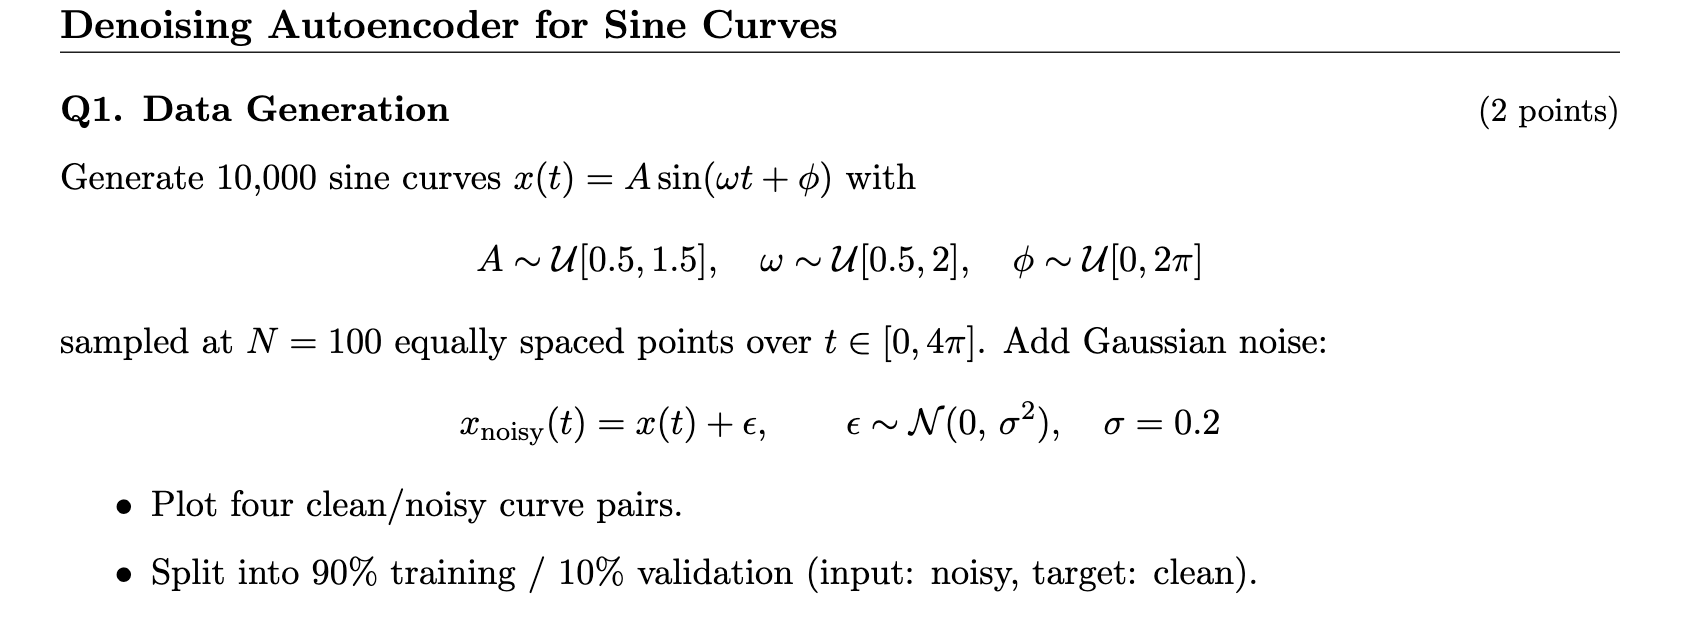

In [6]:
# generate dataset

Q1dataAMP = np.random.uniform(0.5, 1.5, 10000)
Q1dataW = np.random.uniform(0.5, 2, 10000)
Q1dataPhase = np.random.uniform(0, 2*np.pi, 10000)

actualsin = np.zeros((10000, 100))
for i in range(10000):
    for j in range(100):
        actualsin[i][j] = Q1dataAMP[i]*np.sin(Q1dataW[i]*j + Q1dataPhase[i])

#print (actualsin)
print (actualsin.shape)

(10000, 100)


In [7]:
#for i in range (len(actualsin)):
  #print (actualsin[i][-1])

#plt.plot (actualsin[1])
#print (actualsin[55][99])

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [8]:
noisy_curve=np.zeros((10000,100))

# The noise array should have the same shape as actualsin for element-wise addition
noise = np.random.normal(0, 0.2, actualsin.shape) # Generate noise with shape (10000, 100)
noisy_curve = actualsin + noise

# The original print statement for debugging
#print (len (actualsin[1]))

Plot examples showing the clean and noisy curve.

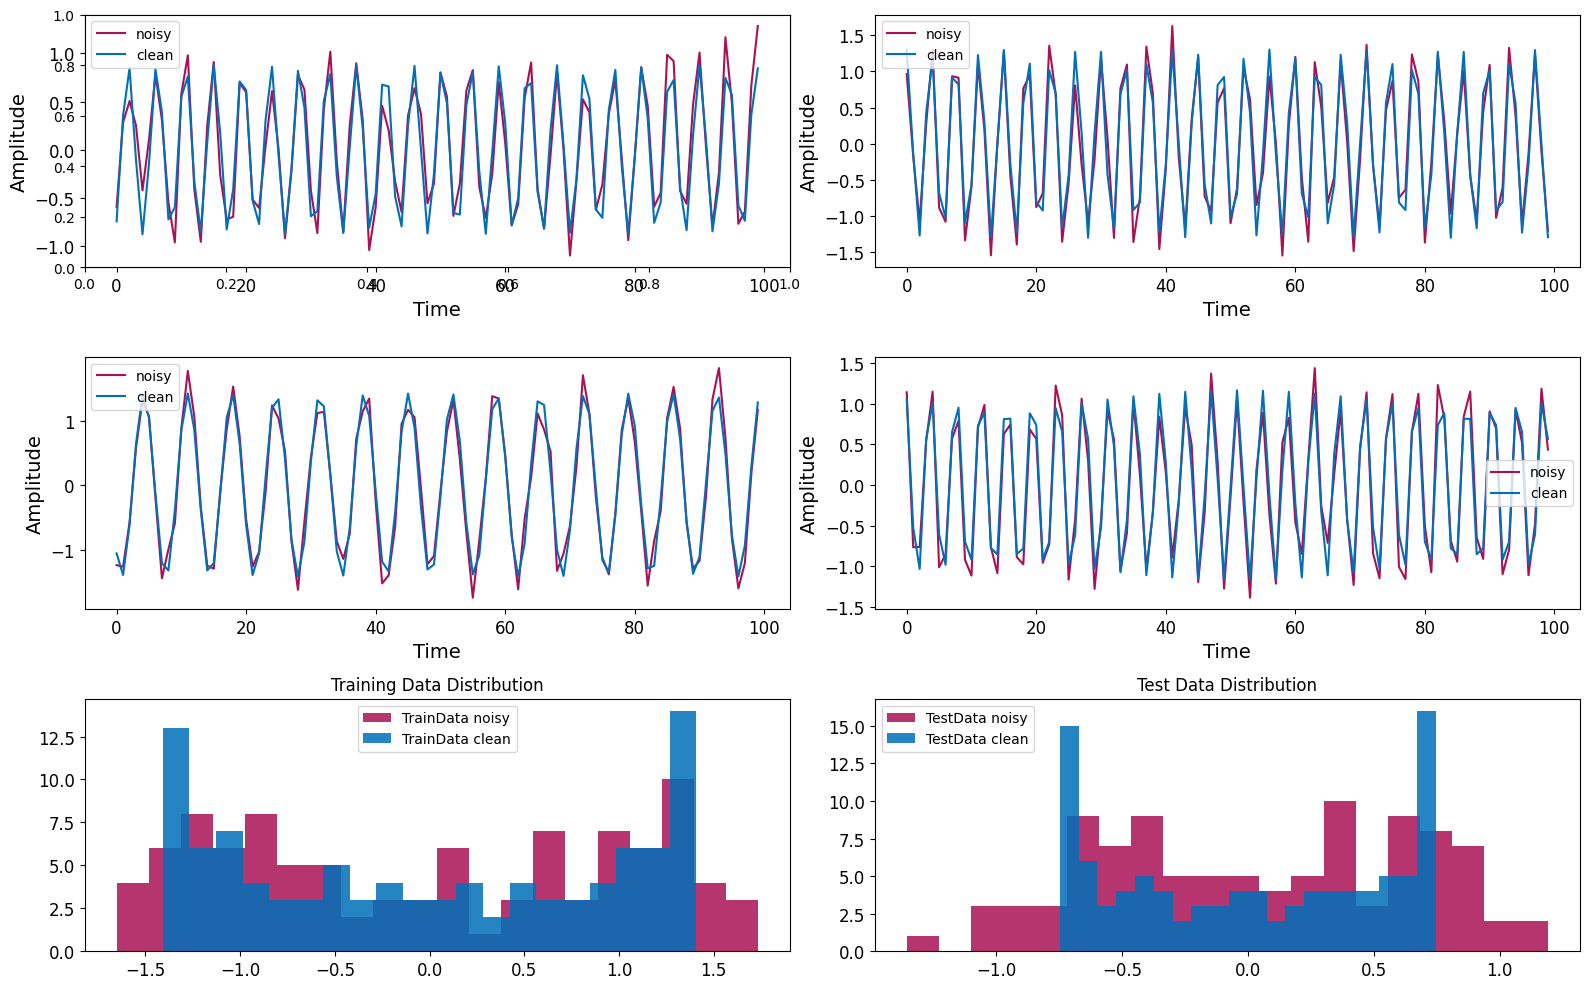

In [9]:
color1,color2,color3,color4,color5 = '#016FB9','#AA1155','#2F4B26','#6CAE75','#330036'

list4 = [1,2,3,4]

fig = plt.figure(figsize=(16,10))

ax=fig.add_subplot(3,2,1)
#ax.plot(noisy_curve[5],label="noisy")
#ax.plot(actualsin[5],label = "clean")
for i in range (len(list4)):
  i=i+1
  ax=fig.add_subplot(3,2,i)

  ax.plot(noisy_curve[i],label="noisy", color=color2)
  ax.plot(actualsin[i],label = "clean", color=color1)


  ax.legend()
  ax.set_xlabel("Time", fontsize=14)
  ax.set_ylabel("Amplitude", fontsize=14)
  ax.tick_params(axis='both', labelsize=12)

# Now split off the training data
#definitly am not doing this quite right. Are we supposed to split the individual sin and noise data or the number of sin and noise curves?
num_samples = noisy_curve.shape[0]
indices = np.random.permutation(num_samples)
split_point = int(0.90 * num_samples)
train_indices = indices[:split_point]
val_indices = indices[split_point:]

x_train = noisy_curve[train_indices]
y_train = actualsin[train_indices]
x_val = noisy_curve[val_indices]
y_val = actualsin[val_indices]




#Plot the clean vs noisy in the training and test sample
ax5 = fig.add_subplot(3,2,5)
ax5.hist(x_train[55],label="TrainData noisy",color=color2,alpha=.85,bins=20)
ax5.hist(y_train[55],label = "TrainData clean",color=color1,alpha=.85,bins=20)

ax5.set_title("Training Data Distribution")
ax5.legend()
ax5.tick_params(axis='both', labelsize=12)


ax6 = fig.add_subplot(3,2,6)
ax6.hist(x_val[55],label="TestData noisy",color=color2,alpha=.85,bins=20)
ax6.hist(y_val[55],label = "TestData clean",color=color1,alpha=.85,bins=20)



ax6.set_title("Test Data Distribution")
ax6.legend()
ax6.tick_params(axis='both', labelsize=12)


plt.tight_layout()
#plt.savefig("fig1.png")

plt.show()

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [10]:
# dataset split

##ahh didnt need to do split in prb1

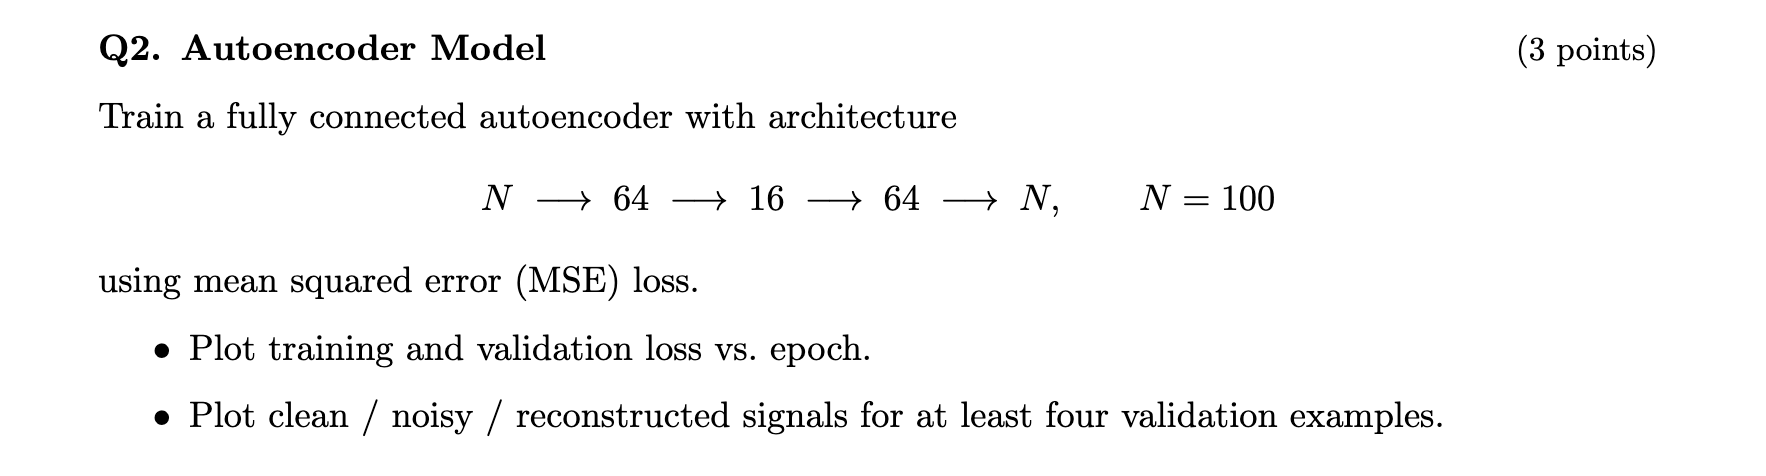

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [11]:
N = 100

In [12]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [13]:
#bringing over my xtrain and ytrain data.




history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5334 - val_loss: 0.5197
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4619 - val_loss: 0.4501
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4069 - val_loss: 0.4097
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3733 - val_loss: 0.3822
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3488 - val_loss: 0.3602
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3278 - val_loss: 0.3406
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3084 - val_loss: 0.3218
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2910 - val_loss: 0.3045
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2762 - val_loss: 0.2916
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2638 - val_loss: 0.2797
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2528 - val_loss: 0.2697
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2430 - val_lo

Plot the training and validation loss curves.

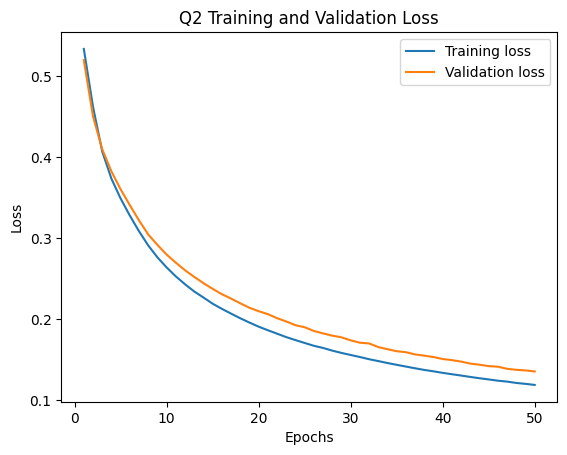

In [14]:
# plot loss curves
plt.plot(epochs_range, train_loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.title('Q2 Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()


## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [15]:
examples = [0, 1, 2, 3]
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

#examples = [0, 1]
reconstructed_Y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


Plot the clean signal, noisy input, and reconstructed signal.

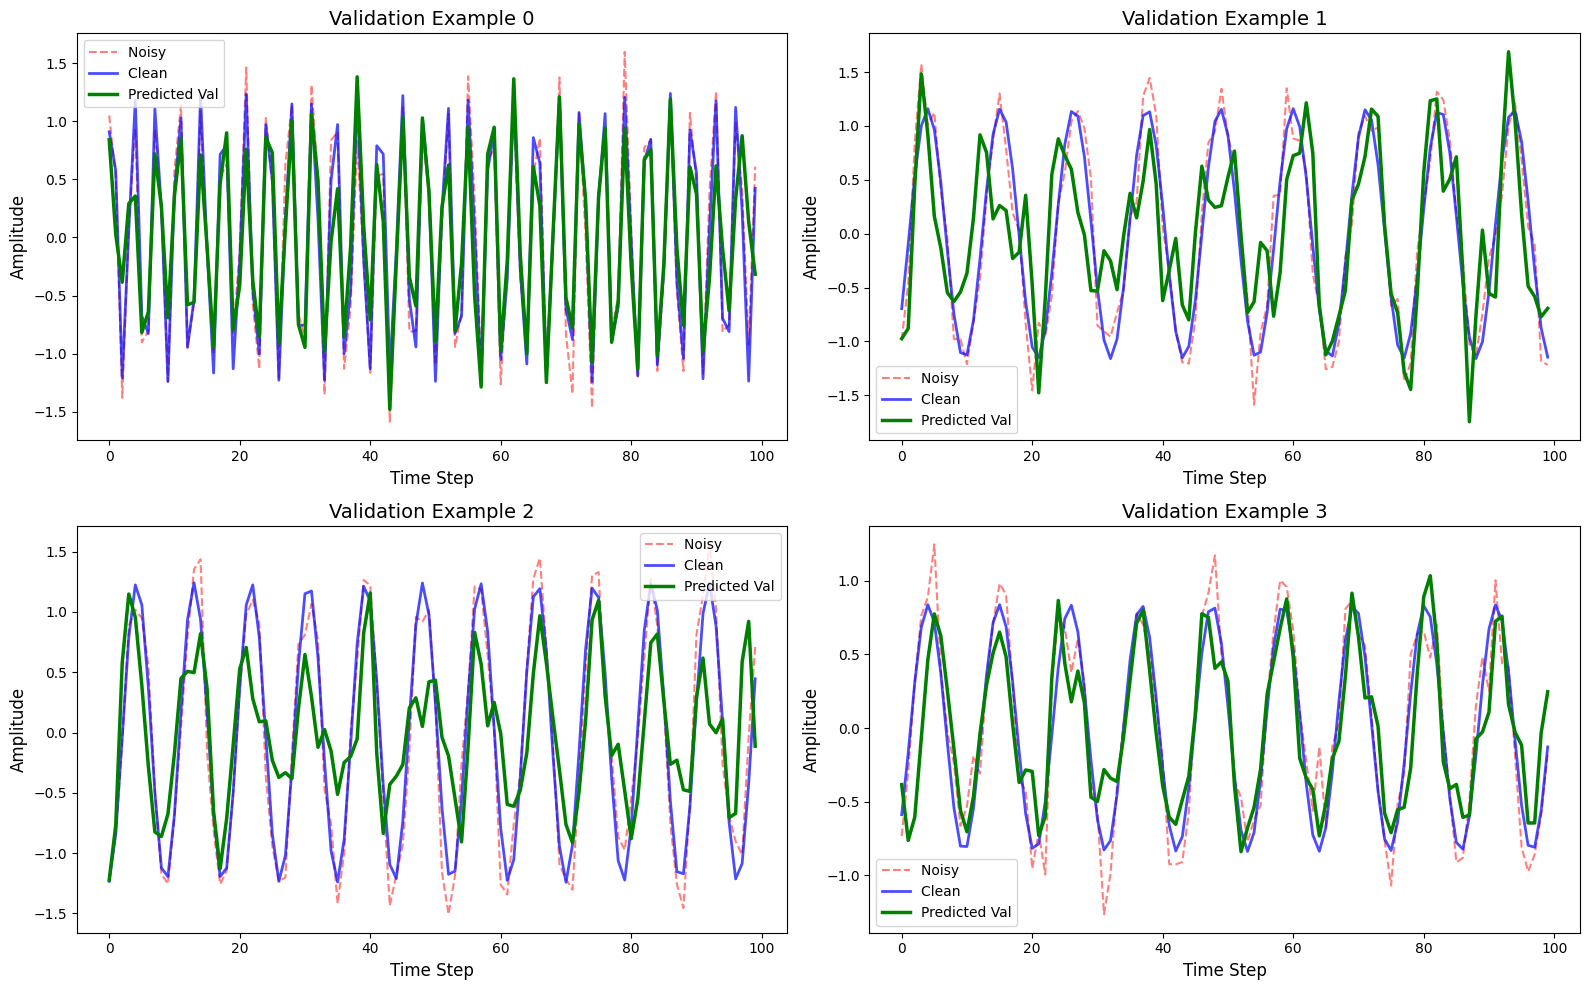

In [16]:

fig = plt.figure(figsize=(16, 10))
for i in range(len(examples)):
    idx = examples[i]
    ax = fig.add_subplot(2, 2, i + 1)
    ax.plot(x_val[idx], label='Noisy ', color='red', alpha=0.5, linestyle='--')

    #  Plot what it SHOULD look like
    ax.plot(y_val[idx], label='Clean ', color='blue', alpha=0.7, linewidth=2)

    #actual val
    ax.plot(reconstructed_Y[i], label='Predicted Val', color='green', linewidth=2.5)


    ax.set_title(f'Validation Example {idx}', fontsize=14)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

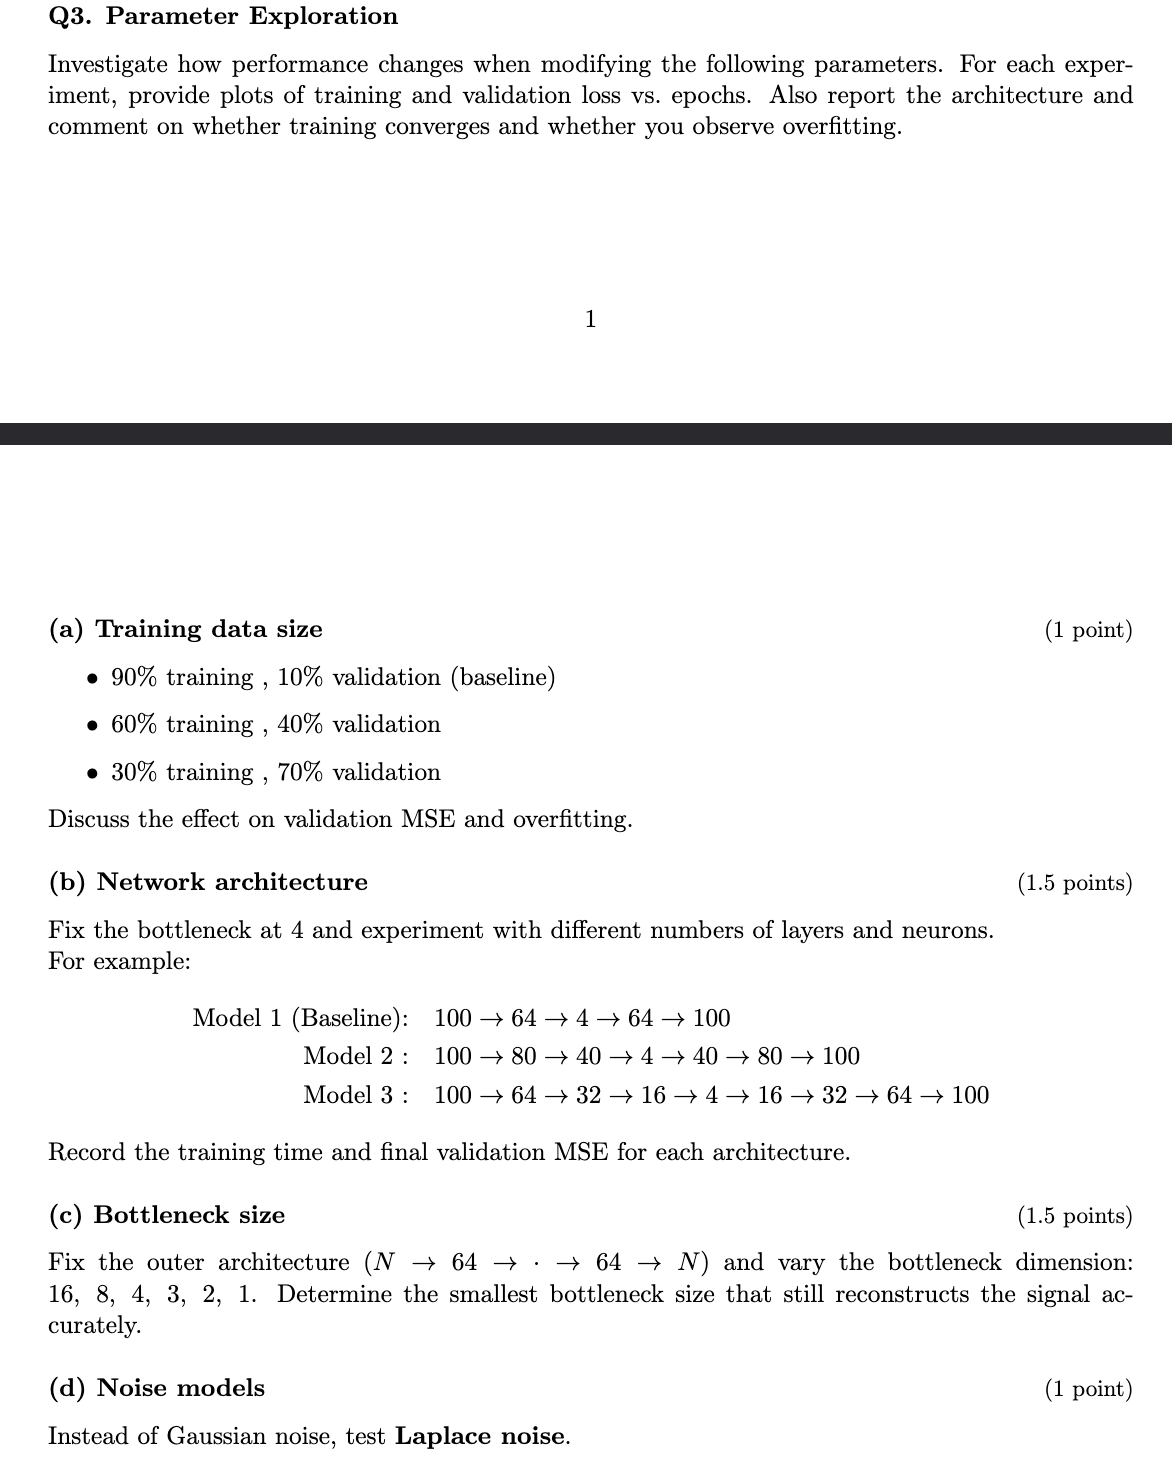